# 10. Evaluate Localization-only GT-E2E

기존 semantic `baseline`/`shared_e2e`와 localization-only 모델을 동일한 class-agnostic 조건으로 비교합니다. 모든 prediction/GT label을 `object=0`으로 통일하므로 semantic class 정답 여부가 localization 지표에 섞이지 않습니다.

두 종류의 결과를 함께 봅니다.

- `loc_mAP/AP50/AP75/AR100`: score ranking까지 포함한 실제 localization 성능
- `matched IoU`, center/size error, geometry recall: top-100 query box 자체의 기하 품질

In [1]:
from pathlib import Path
import gc, importlib, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.model as model_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
model_module = importlib.reload(model_module)
eval_module = importlib.reload(eval_module)

ExperimentConfig = config_module.ExperimentConfig
prepare_data, make_loaders = data_module.prepare_data, data_module.make_loaders
load_checkpoint = eval_module.load_checkpoint
evaluate_main = eval_module.evaluate_main
collect_localization_predictions = eval_module.collect_localization_predictions
localization_metrics = eval_module.localization_metrics
localization_geometry_metrics = eval_module.localization_geometry_metrics

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43]
DATA_SEED = 42
EXPERIMENTS = [
    'baseline',
    'shared_e2e',
    'localization_only',
    'localization_gt_e2e_aux010',
    'localization_gt_e2e_aux025',
    'localization_gt_e2e_aux050',
]
SEMANTIC_EXPERIMENTS = {'baseline', 'shared_e2e'}
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 384, 640
STRICT_CHECKPOINTS = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_min_size=IMAGE_MIN_SIZE,
    image_max_size=IMAGE_MAX_SIZE, feature_level=0,
)
CONFIG.as_dict()

{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline',
  'shared_e2e',
  'localization_only',
  'localization_gt_e2e_aux010',
  'localization_gt_e2e_aux025',
  'localization_gt_e2e_aux050'],
 'seed': 42,
 'data_seed': 42}

In [3]:
BUNDLE = prepare_data(CONFIG)
checkpoint_rows = []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        path = CONFIG.checkpoint_path(experiment, seed)
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(), 'path': str(path)
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
missing = checkpoint_df.loc[~checkpoint_df['exists']]
if STRICT_CHECKPOINTS and not missing.empty:
    raise FileNotFoundError(
        'Missing checkpoints. Run 01_train_experiments.ipynb and ' +
        '01-3_train_localization_only_gt_e2e.ipynb first:\n' +
        '\n'.join(missing['path'])
    )

VOC XML: 100%|██████████| 3750/3750 [00:06<00:00, 584.81it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100


,experiment,seed,exists,path
0,baseline,42,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
1,baseline,43,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
2,shared_e2e,42,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
3,shared_e2e,43,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
4,localization_only,42,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
5,localization_only,43,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
6,localization_gt_e2e_aux010,42,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
7,localization_gt_e2e_aux010,43,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
8,localization_gt_e2e_aux025,42,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...
9,localization_gt_e2e_aux025,43,True,D:\gt-super\cache\checkpoints\checkpoint_smoke...


In [4]:
rows, semantic_rows = [], []
available = checkpoint_df.loc[checkpoint_df['exists'], ['experiment', 'seed']]
for experiment, seed in available.itertuples(index=False):
    print(f'[{experiment} / seed={seed}]')
    _, val_loader = make_loaders(CONFIG, BUNDLE, seed)
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    predictions = targets = None
    try:
        predictions, targets = collect_localization_predictions(
            model, val_loader, BUNDLE.processor, CONFIG
        )
        row = {
            'experiment': experiment, 'seed': seed,
            'checkpoint_epoch': checkpoint.get('epoch'), 'fingerprint': fingerprint,
            **localization_metrics(predictions, targets),
            **localization_geometry_metrics(predictions, targets, max_detections=100),
        }
        rows.append(row)
        if experiment in SEMANTIC_EXPERIMENTS:
            semantic_rows.append({
                'experiment': experiment, 'seed': seed,
                **evaluate_main(model, val_loader, BUNDLE.processor, CONFIG),
            })
        print({key: round(value, 4) for key, value in row.items()
               if key in {'loc_map', 'loc_ap50', 'loc_ap75', 'loc_ar100',
                          'matched_iou', 'center_error_l2', 'size_error_l1'}})
    finally:
        model.close()
        model.cpu()
        del model, predictions, targets
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = pd.DataFrame(rows)
semantic_df = pd.DataFrame(semantic_rows)
raw_path = CONFIG.output_dir / 'localization_only_comparison_raw.csv'
semantic_path = CONFIG.output_dir / 'localization_only_semantic_reference.csv'
results_df.to_csv(raw_path, index=False)
semantic_df.to_csv(semantic_path, index=False)
print('Saved:', raw_path)
print('Saved:', semantic_path)

[baseline / seed=42]


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 18410.15it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

{'loc_map': 0.1251, 'loc_ap50': 0.2461, 'loc_ap75': 0.1121, 'loc_ar100': 0.5794, 'matched_iou': 0.7309, 'center_error_l2': 0.0429, 'size_error_l1': 0.0841}
[baseline / seed=43]


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 17004.99it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

{'loc_map': 0.1797, 'loc_ap50': 0.3328, 'loc_ap75': 0.1758, 'loc_ar100': 0.5942, 'matched_iou': 0.7406, 'center_error_l2': 0.0381, 'size_error_l1': 0.0819}
[shared_e2e / seed=42]


...

{'loc_map': 0.2805, 'loc_ap50': 0.4802, 'loc_ap75': 0.2847, 'loc_ar100': 0.6579, 'matched_iou': 0.7995, 'center_error_l2': 0.0179, 'size_error_l1': 0.0492}
[localization_gt_e2e_aux050 / seed=42]


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 17355.52it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.ba

{'loc_map': 0.2246, 'loc_ap50': 0.3958, 'loc_ap75': 0.2361, 'loc_ar100': 0.6563, 'matched_iou': 0.7903, 'center_error_l2': 0.0205, 'size_error_l1': 0.0529}
[localization_gt_e2e_aux050 / seed=43]


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 15529.82it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.ba

{'loc_map': 0.2276, 'loc_ap50': 0.4102, 'loc_ap75': 0.2225, 'loc_ar100': 0.6421, 'matched_iou': 0.7875, 'center_error_l2': 0.0197, 'size_error_l1': 0.051}
Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_comparison_raw.csv
Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_semantic_reference.csv


In [5]:
METRICS = [
    'loc_map', 'loc_ap50', 'loc_ap75', 'loc_ar100',
    'loc_ap_small', 'loc_ap_medium', 'loc_ap_large',
    'matched_iou', 'center_error_l2', 'size_error_l1',
    'geometry_recall50', 'geometry_recall75',
]
summary = results_df.groupby('experiment')[METRICS].agg(['mean', 'std', 'count'])
summary_path = CONFIG.output_dir / 'localization_only_comparison_summary.csv'
summary.to_csv(summary_path)
display(summary)
print('Saved:', summary_path)

# 같은 seed끼리 뺀 paired delta: 양수 우위 지표와 음수 우위 error 지표를 그대로 보존합니다.
delta_frames = []
for reference in ['baseline', 'shared_e2e', 'localization_only']:
    reference_df = results_df.query('experiment == @reference').set_index('seed')[METRICS]
    for experiment in results_df['experiment'].unique():
        if experiment == reference:
            continue
        candidate = results_df.query('experiment == @experiment').set_index('seed')[METRICS]
        common = candidate.index.intersection(reference_df.index)
        if common.empty:
            continue
        delta = candidate.loc[common] - reference_df.loc[common]
        delta['experiment'] = experiment
        delta['reference'] = reference
        delta['seed'] = common
        delta_frames.append(delta.reset_index(drop=True))
paired_delta_df = pd.concat(delta_frames, ignore_index=True)
delta_path = CONFIG.output_dir / 'localization_only_paired_deltas.csv'
paired_delta_df.to_csv(delta_path, index=False)
display(paired_delta_df.groupby(['reference', 'experiment'])[METRICS].mean())
print('Saved:', delta_path)

loc_map                  loc_ap50            \
                                mean       std count      mean       std   
experiment                                                                 
baseline                    0.152392  0.038659     2  0.289433  0.061342   
localization_gt_e2e_aux010  0.278232  0.002255     2  0.473638  0.029762   
localization_gt_e2e_aux025  0.250629  0.042208     2  0.429359  0.071871   
localization_gt_e2e_aux050  0.226087  0.002086     2  0.402984  0.010167   
localization_only           0.261126  0.013412     2  0.476208  0.012837   
shared_e2e                  0.150226  0.008120     2  0.274200  0.019807   

                                  loc_ap75                 loc_ar100  ...  \
                           count      mean       std count      mean  ...   
experiment                                                            ...   
baseline                       2  0.143961  0.045037     2  0.586817  ...   
localization_gt_e2e_aux010     2  0.309823  0.000038     2  0.649839  ...   
localization_gt_e2e_aux025     2  0.255927  0.040655     2  0.648875  ...   
localization_gt_e2e_aux050     2  0.229297  0.009596     2  0.649196  ...   
localization_only              2  0.250685  0.003272     2  0.625563  ...   
shared_e2e                     2  0.143786  0.005719     2  0.610932  ...   

                           center_error_l2 size_error_l1                  \
                                     count          mean       std count   
experiment                                                                 
baseline                                 2      0.082960  0.001551     2   
localization_gt_e2e_aux010               2      0.050976  0.005009     2   
localization_gt_e2e_aux025               2      0.052176  0.004196     2   
localization_gt_e2e_aux050               2      0.051974  0.001359     2   
localization_only                        2      0.055106  0.000284     2   
shared_e2e                               2      0.076084  0.002141     2   

                           geometry_recall50                  \
                                        mean       std count   
experiment                                                     
baseline                            0.860129  0.015916     2   
localization_gt_e2e_aux010          0.937299  0.011368     2   
localization_gt_e2e_aux025          0.927653  0.029558     2   
localization_gt_e2e_aux050          0.934084  0.006821     2   
localization_only                   0.932476  0.004547     2   
shared_e2e                          0.868167  0.031831     2   

                           geometry_recall75                  
                                        mean       std count  
experiment                                                    
baseline                            0.641479  0.020463     2  
localization_gt_e2e_aux010          0.728296  0.052294     2  
localization_gt_e2e_aux025          0.702572  0.002274     2  
localization_gt_e2e_aux050          0.707395  0.013642     2  
localization_only                   0.665595  0.022737     2  
shared_e2e                          0.659164  0.013642     2  

[6 rows x 36 columns]

Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_comparison_summary.csv


loc_map  loc_ap50  loc_ap75  \
reference         experiment                                                 
baseline          localization_gt_e2e_aux010  0.125840  0.184206  0.165861   
                  localization_gt_e2e_aux025  0.098238  0.139927  0.111965   
                  localization_gt_e2e_aux050  0.073695  0.113551  0.085336   
                  localization_only           0.108734  0.186775  0.106724   
                  shared_e2e                 -0.002166 -0.015233 -0.000175   
localization_only baseline                   -0.108734 -0.186775 -0.106724   
                  localization_gt_e2e_aux010  0.017106 -0.002569  0.059138   
                  localization_gt_e2e_aux025 -0.010497 -0.046848  0.005241   
                  localization_gt_e2e_aux050 -0.035039 -0.073224 -0.021388   
                  shared_e2e                 -0.110900 -0.202008 -0.106899   
shared_e2e        baseline                    0.002166  0.015233  0.000175   
                  localization_gt_e2e_aux010  0.128005  0.199439  0.166037   
                  localization_gt_e2e_aux025  0.100403  0.155159  0.112140   
                  localization_gt_e2e_aux050  0.075861  0.128784  0.085511   
                  localization_only           0.110900  0.202008  0.106899   

                                              loc_ar100  loc_ap_small  \
reference         experiment                                            
baseline          localization_gt_e2e_aux010   0.063022     -0.007391   
                  localization_gt_e2e_aux025   0.062058      0.013126   
                  localization_gt_e2e_aux050   0.062379      0.018211   
                  localization_only            0.038746      0.062749   
                  shared_e2e                   0.024116     -0.009898   
localization_only baseline                    -0.038746     -0.062749   
                  localization_gt_e2e_aux010   0.024277     -0.070139   
                  localization_gt_e2e_aux025   0.023312     -0.049623   
                  localization_gt_e2e_aux050   0.023633     -0.044537   
                  shared_e2e                  -0.014630     -0.072647   
shared_e2e        baseline                    -0.024116      0.009898   
                  localization_gt_e2e_aux010   0.038907      0.002508   
                  localization_gt_e2e_aux025   0.037942      0.023024   
                  localization_gt_e2e_aux050   0.038264      0.028109   
                  localization_only            0.014630      0.072647   

                                              loc_ap_medium  loc_ap_large  \
reference         experiment                                                
baseline          localization_gt_e2e_aux010       0.058295      0.164469   
                  localization_gt_e2e_aux025       0.055049      0.136289   
                  localization_gt_e2e_aux050       0.054827      0.099114   
                  localization_only                0.078965      0.140599   
                  shared_e2e                       0.024806     -0.031157   
localization_only baseline                        -0.078965     -0.140599   
                  localization_gt_e2e_aux010      -0.020670      0.023870   
                  localization_gt_e2e_aux025      -0.023915     -0.004309   
                  localization_gt_e2e_aux050      -0.024137     -0.041485   
                  shared_e2e                      -0.054158     -0.171755   
shared_e2e        baseline                        -0.024806      0.031157   
                  localization_gt_e2e_aux010       0.033488      0.195626   
                  localization_gt_e2e_aux025       0.030243      0.167446   
                  localization_gt_e2e_aux050       0.030021      0.130271   
                  localization_only                0.054158      0.171755   

                                              matched_iou  center_error_l2  \
reference         experiment                                                 
baseline    

Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_paired_deltas.csv


Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_comparison.png


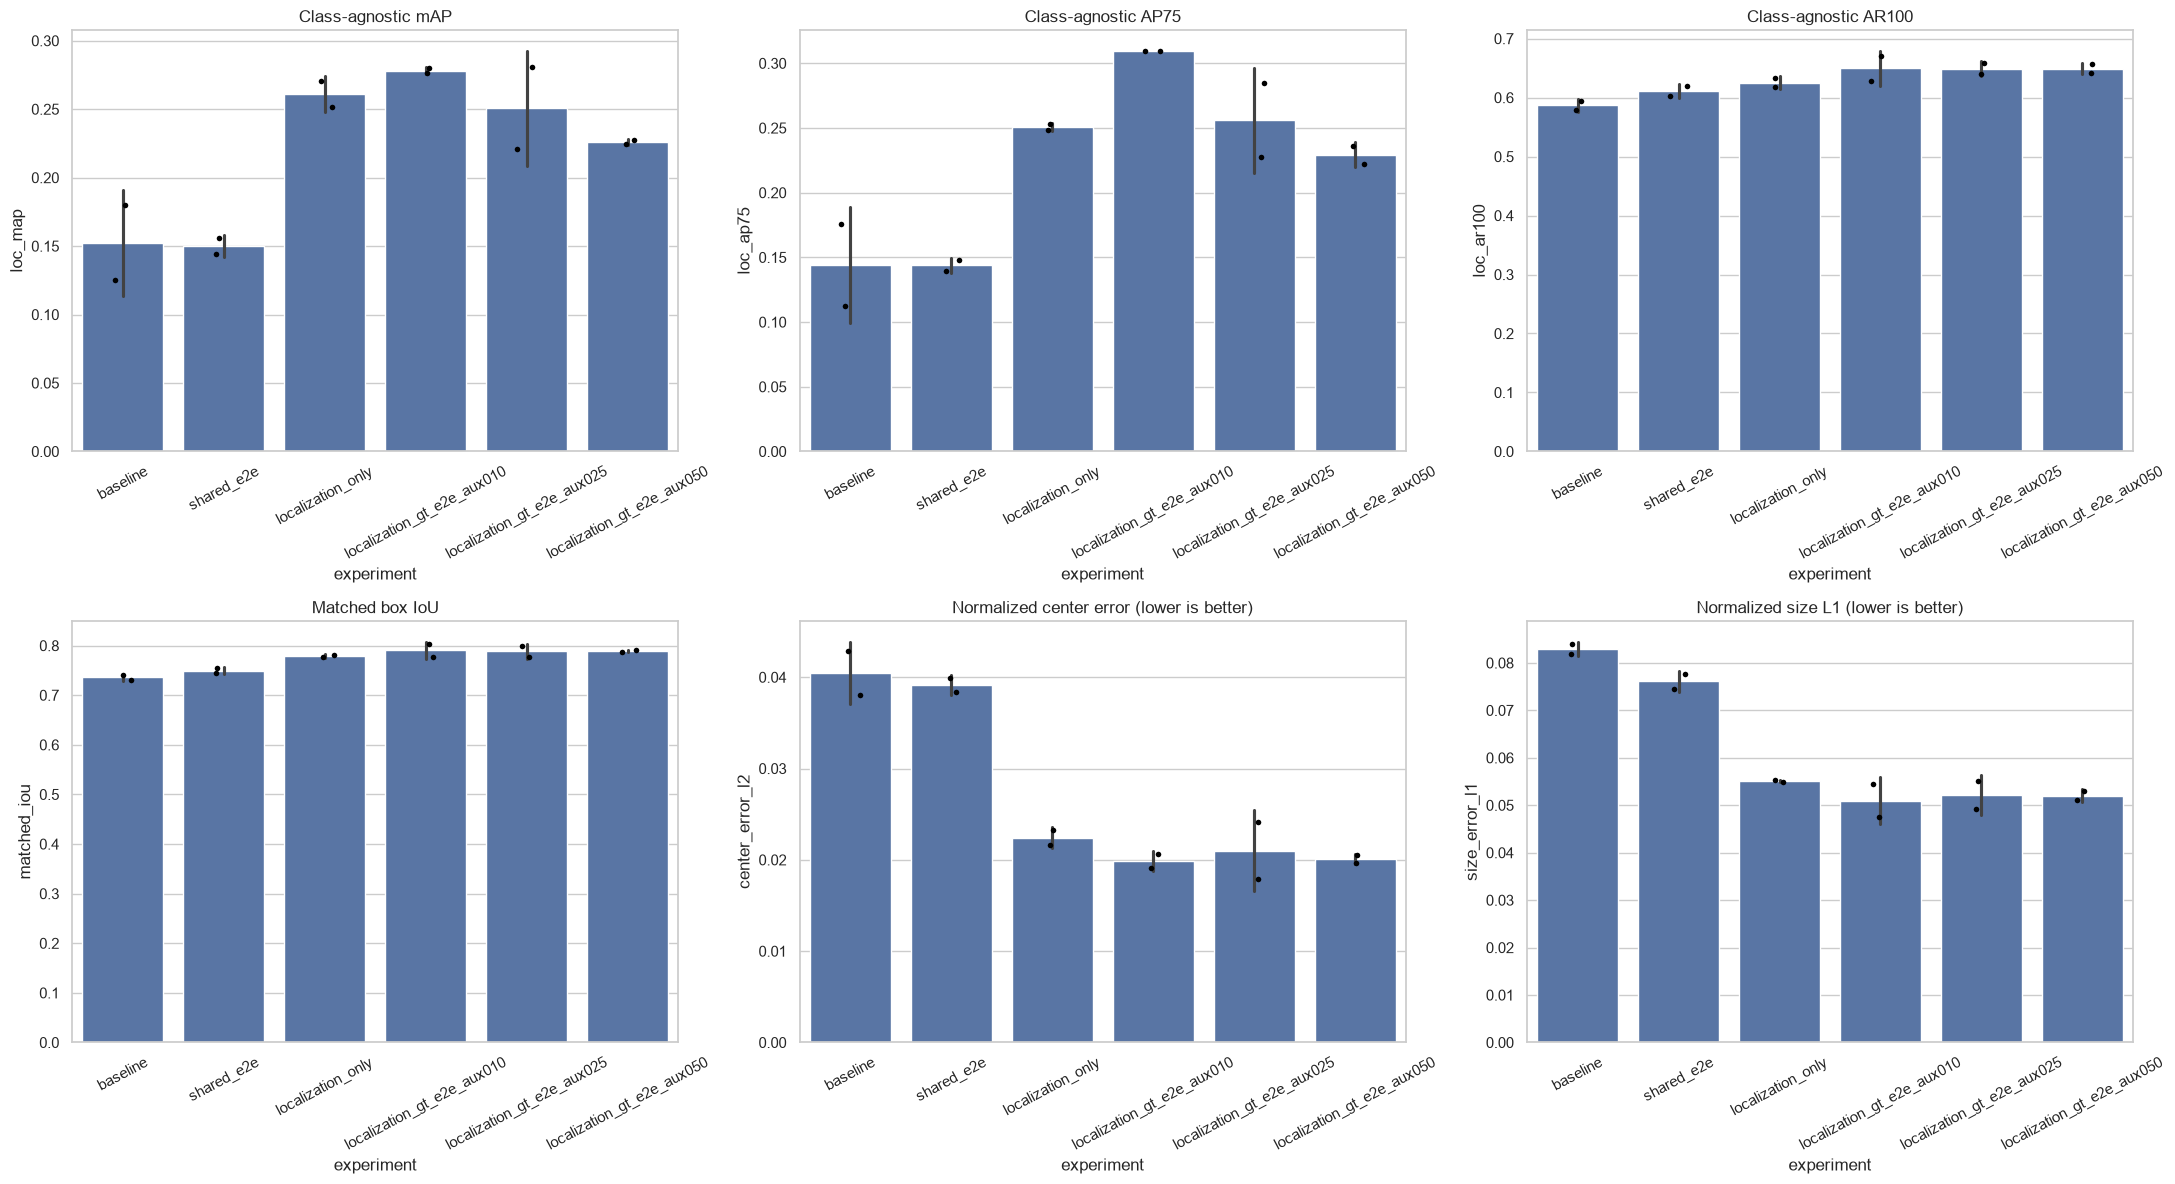

In [6]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
plot_specs = [
    ('loc_map', 'Class-agnostic mAP', False),
    ('loc_ap75', 'Class-agnostic AP75', False),
    ('loc_ar100', 'Class-agnostic AR100', False),
    ('matched_iou', 'Matched box IoU', False),
    ('center_error_l2', 'Normalized center error (lower is better)', True),
    ('size_error_l1', 'Normalized size L1 (lower is better)', True),
]
for axis, (metric, title, lower_is_better) in zip(axes.flat, plot_specs):
    sns.barplot(data=results_df, x='experiment', y=metric, errorbar='sd', ax=axis)
    sns.stripplot(data=results_df, x='experiment', y=metric, color='black', size=4, ax=axis)
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=28)
plt.tight_layout()
figure_path = CONFIG.output_dir / 'localization_only_comparison.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
print('Saved:', figure_path)
plt.show()

Saved: D:\gt-super\outputs\detr_gt_auxiliary\localization_only_scale_ap.png


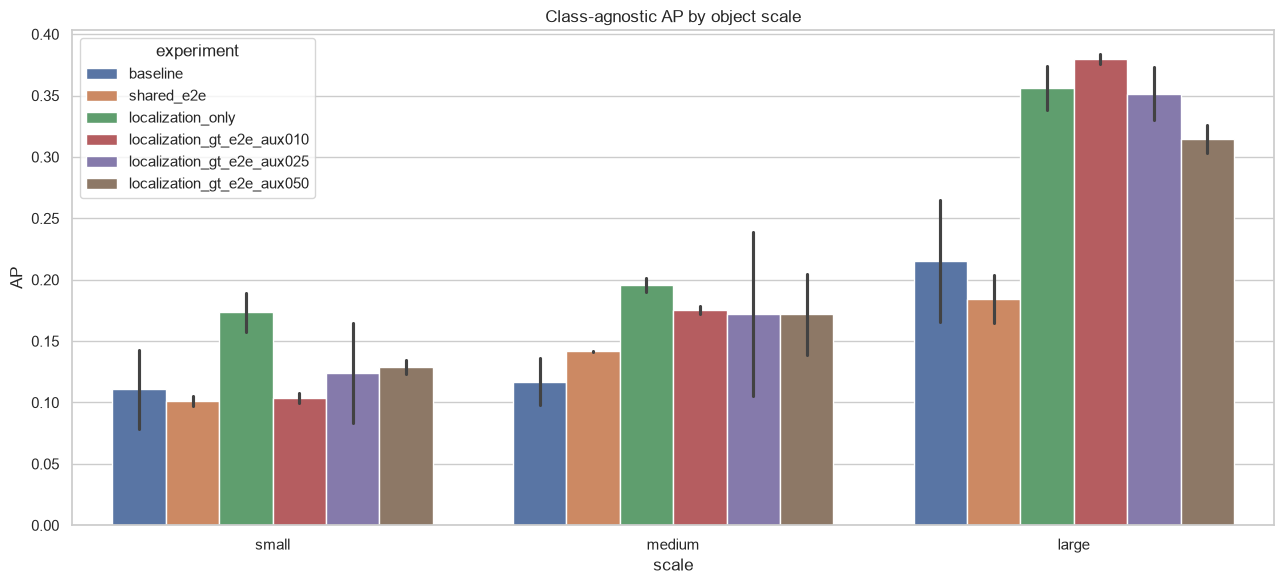

Semantic detection reference (localization-only 모델에는 정의되지 않음)


map               map50               map75            \
                mean       std      mean       std      mean       std   
experiment                                                               
baseline    0.081581  0.030700  0.136100  0.036695  0.084421  0.035557   
shared_e2e  0.088484  0.026641  0.142578  0.039555  0.090512  0.021327   

              mar100            
                mean       std  
experiment                      
baseline    0.414599  0.032673  
shared_e2e  0.399471  0.007447

In [7]:
scale_df = results_df.melt(
    id_vars=['experiment', 'seed'],
    value_vars=['loc_ap_small', 'loc_ap_medium', 'loc_ap_large'],
    var_name='scale', value_name='AP',
)
scale_df['scale'] = scale_df['scale'].str.replace('loc_ap_', '', regex=False)
fig, axis = plt.subplots(figsize=(13, 6))
sns.barplot(data=scale_df, x='scale', y='AP', hue='experiment', errorbar='sd', ax=axis)
axis.set_title('Class-agnostic AP by object scale')
plt.tight_layout()
scale_path = CONFIG.output_dir / 'localization_only_scale_ap.png'
fig.savefig(scale_path, dpi=180, bbox_inches='tight')
print('Saved:', scale_path)
plt.show()

print('Semantic detection reference (localization-only 모델에는 정의되지 않음)')
display(semantic_df.groupby('experiment')[['map', 'map50', 'map75', 'mar100']].agg(['mean', 'std']))

## 판정 기준

제안 효과는 먼저 `localization_gt_e2e_* - localization_only`의 paired delta로 판단합니다. AP/AR/matched IoU/recall은 양수, center·size error는 음수이면 개선입니다. 그다음 `baseline`과 `shared_e2e` 대비 절대 수준을 확인합니다. `lambda_aux` 선택은 평균 성능뿐 아니라 seed 표준편차와 학습 노트북의 aux/main gradient norm ratio(권장 0.3~0.7)를 함께 봅니다.